<a href="https://colab.research.google.com/github/dmandache/IMPERANDI/blob/examples%2Ftcga-lihc-cohorts/examples/demos/demo_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPERANDI × TCGA-LIHC — Full demo

A public end-to-end walkthrough using the same three TCGA-LIHC patients as the light demo. This notebook demonstrates **ingest → phase curation → convert → segmentation → interactive viewer**.

Radiomics installation and commands are included but intentionally commented out.

## 1. Install IMPERANDI with all runtime features

`.[all]` installs segmentation and viewer dependencies. PyRadiomics is intentionally installed separately because IMPERANDI keeps it out of package metadata.

In [1]:
%cd /content
![ -d /content/IMPERANDI/.git ] || git clone --depth 1 --branch examples/tcga-lihc-cohorts https://github.com/dmandache/IMPERANDI.git
%cd /content/IMPERANDI
!python -m pip install .[all]
!python -m pip install idc-index
# PyRadiomics must be installed separately when you want to enable the commented radiomics step below.
!python -m pip install 'pyradiomics @ git+https://github.com/AIM-Harvard/pyradiomics.git@master'


/content
Cloning into 'IMPERANDI'...
remote: Enumerating objects: 197, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 197 (delta 9), reused 77 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (197/197), 3.04 MiB | 13.63 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/IMPERANDI
Processing /content/IMPERANDI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of fury to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import imperandi
print(imperandi.__file__)

/usr/local/lib/python3.13/dist-packages/imperandi/__init__.py


## 2. Download the same three public patients

In [3]:
!python examples/benchmarks/download.py /content/TCGA-LIHC-demo \
  --patient TCGA-BC-A10Y \
  --patient TCGA-DD-A113 \
  --patient TCGA-DD-A4NJ

{
  "idc_version": "v25",
  "idc_index_version": "0.13.0",
  "patients": 3,
  "series": 92,
  "estimated_size_MB": 2754.683624,
  "dry_run": false
}
2026-10-08 12:54:22,392 - Disk size needed: 2.75 GB
2026-10-08 12:54:22,392 - Disk size available: 91.8 GB
2026-10-08 12:54:53,846 - 
stoud from s5cmd sync dry run is not empty. Parsing the output to
evaluate what to download and corresponding size with only series level precision

2026-10-08 12:54:53,847 - Parsing the s5cmd sync dry run output...
2026-10-08 12:54:53,938 - Parsing the s5cmd sync dry run output finished
2026-10-08 12:54:53,938 - sync_size (MB): 2754.68
2026-10-08 12:54:53,942 - Initial size of the directory: 0 bytes
2026-10-08 12:54:53,945 - Approximate size of the files that need to be downloaded: 2.75 GB


### Inspect the downloaded series

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

selection = pd.read_csv('/content/TCGA-LIHC-demo/idc_selection.csv')
display(selection[['PatientID','Modality','StudyInstanceUID','SeriesInstanceUID','series_size_MB']])
display(
    selection.groupby(['PatientID', 'Modality'])
    .agg(
        studies=('StudyInstanceUID', 'nunique'),
        series=('SeriesInstanceUID', 'nunique'),
    )
)

,PatientID,Modality,StudyInstanceUID,SeriesInstanceUID,series_size_MB
0,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.112954049272...,7.527276
1,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.146521872880...,4.557298
2,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.210105385864...,3.349438
3,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.222111668590...,4.557388
4,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.235620519037...,7.526258
...,...,...,...,...,...
87,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.312823803664...,57.948674
88,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.315096169381...,6.418184
89,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.345436872573...,34.862056
90,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.377152448922...,4.420734


studies  series
PatientID    Modality                 
TCGA-BC-A10Y MR              2      24
TCGA-DD-A113 CT              4      17
             MR              1      10
TCGA-DD-A4NJ CT              3      22
             MR              1      19

## 3. Ingest

In [5]:
!mkdir -p /content/imperandi-demo/tables
!imperandi ingest \
  /content/TCGA-LIHC-demo \
  /content/imperandi-demo/tables \
  --manifest examples/demos/demo_manifest.yaml \
  --id_source tags \
  --patient_key_from PatientID \
  --study_id_from StudyInstanceUID \
  --series_id_from SeriesInstanceUID \
  --num_workers 2

2026-10-08 12:56:04 | INFO     | imperandi.cli | Running parse.py with arguments:
{   'archive_cache_dir': None,
    'archive_detect_sample_size': 128,
    'archive_max_depth': 3,
    'checkpoint_every_rows': 10000,
    'checkpoint_every_sec': 300,
    'command': 'ingest',
    'csv_path_out': None,
    'dry_run': False,
    'force_dicom_read': False,
    'id_source': 'tags',
    'keep_archive_cache': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'num_workers': 2,
    'output_dir': '/content/imperandi-demo/tables',
    'patient_key_from': 'PatientID',
    'quiet': False,
    'resume': True,
    'root_path': '/content/TCGA-LIHC-demo',
    'series_id_from': 'SeriesInstanceUID',
    'snapshot_sample_size': 500,
    'snapshot_seed': 42,
    'snapshot_tags': False,
    'strict_resume': False,
    'study_id_from': 'StudyInstanceUID',
    'tags': '',
    'verbose': False}
2026-10-08 12:56:04 | INFO     | imperandi.cli | Running cle

### Inspect ingest outputs

In [6]:
raw = pd.read_csv('/content/imperandi-demo/tables/dicom_index.csv')
clean = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean.csv')

print(f'Parsed DICOM rows: {len(raw):,}')
print(f'Curated volume rows: {len(clean):,}')

print('Volumes by patient and modality:')
display(
    clean.groupby(['patient_key', 'Modality'])
    .agg(
        studies=('study_id', 'nunique'),
        series=('series_id', 'nunique'),
        volumes=('volume_id', 'nunique'),
    )
)

print('Representative curated volumes:')
clean_cols = [c for c in ['patient_key', 'date', 'Modality', 'SeriesDescription', 'volume_id'] if c in clean.columns]
display(clean[clean_cols].head(10))



Parsed DICOM rows: 5,931
Curated volume rows: 66
Volumes by patient and modality:


studies  series  volumes
patient_key  Modality                          
TCGA-BC-A10Y MR              2       4        4
TCGA-DD-A113 CT              4      13       14
             MR              1       8       13
TCGA-DD-A4NJ CT              3      15       15
             MR              1      15       20

Representative curated volumes:


,patient_key,date,Modality,SeriesDescription,volume_id
0,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,8e645fafd837e284d640f444a606d53608916369
1,TCGA-BC-A10Y,1993-03-21,MR,Subtraction_S11_S9_1,30d17d0c04eaf4f2862f554af44e42fa50e138af
2,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,74e6d13efd2a9cc8e61ffb1bb3e97938800a273a
3,TCGA-BC-A10Y,1993-05-01,MR,VIBE 3D NEW 2002B,3f3f02cda686c10767919269bc39d3396d4162f3
4,TCGA-DD-A113,1998-12-09,MR,ax FSE,7b572adfb1df6d1103fb7a9c0c17b4499552ff8c
5,TCGA-DD-A113,1998-12-09,MR,cor ssfse,ca27c5ba3b7ccbfe98a50db66871d82b40ab8a96
6,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,8fc5aa6d8e71c0aa2dd10f69ff5bbe4204be4050
7,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,dee909af88c497d475069cb88923edabf5fd24cf
8,TCGA-DD-A113,1998-12-09,MR,lava pre,286fed735c02466d126c548eb9e7b8f9debc2b6f
9,TCGA-DD-A113,1998-12-09,MR,realtime,0c05b6b4c6be2afbb405ecbdc415fd6a13e25abf


## 4. Phase curation

Ingest has already generated modality-specific metadata evidence. This task resolves the canonical phase and exports the best candidates, which are then used for the heavier image-processing stages.

In [7]:
!imperandi phase \
  /content/imperandi-demo/tables/dicom_index_clean.csv \
  --csv_path_out /content/imperandi-demo/tables/dicom_index_phased.csv \
  --manifest examples/demos/demo_manifest.yaml

2026-10-08 12:56:29 | INFO     | imperandi.cli | Running phase.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'phase',
    'csv_path': '/content/imperandi-demo/tables/dicom_index_clean.csv',
    'csv_path_out': '/content/imperandi-demo/tables/dicom_index_phased.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/phase_errors.csv',
    'force': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'quiet': False,
    'resume': True,
    'selected_csv_path': None,
    'strict_resume': False,
    'verbose': False}
2026-10-08 12:56:29 | INFO     | imperandi.extract.phase | Phase strategy order: metadata_phase_candidates (rules)
Phase: 0it [00:00, ?it/s]
2026-10-08 12:56:29 | INFO     | imperandi.extract.phase | Phase strategy 1/1: metadata_phase_candidates (rules) resolved 22 volume(s); 19 unresolved
2026-10-08 12:56:29 | INFO     | imperandi.extract.pha

### Inspect phase curation

In [ ]:
phased = pd.read_csv('/content/imperandi-demo/tables/dicom_index_phased.csv')
selected = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean_curated.csv')

phase_counts = (
    phased.groupby(['Modality', 'phase'], dropna=False)
    .size()
    .rename('volumes')
    .reset_index()
)
print('Phase distribution by modality:')
display(phase_counts)

phase_plot = phase_counts.pivot(index='phase', columns='Modality', values='volumes').fillna(0)
ax = phase_plot.plot.bar()
ax.set_xlabel('Phase')
ax.set_ylabel('Volumes')
ax.set_title('Curated phase distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

if 'phase_source' in phased.columns:
    print('Phase provenance:')
    display(phased['phase_source'].value_counts(dropna=False).rename('volumes').to_frame())

if 'phase_status' in phased.columns:
    print('Phase status:')
    display(phased['phase_status'].value_counts(dropna=False).rename('volumes').to_frame())

    unresolved = phased.loc[phased['phase_status'].eq('UNRESOLVED')].copy()

    unresolved_ct = unresolved.loc[unresolved['Modality'].eq('CT')]
    ct_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason', 'ProtocolName',
            'ImageType', 'phase'
        ]
        if c in unresolved_ct.columns
    ]
    print(f'Unresolved CT curation examples ({len(unresolved_ct)} total):')
    display(unresolved_ct[ct_cols].head(10))

    unresolved_mr = unresolved.loc[unresolved['Modality'].isin(['MR', 'MRI'])]
    mr_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason', 'ProtocolName',
            'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'ScanningSequence', 'SequenceName',
            'RepetitionTime', 'EchoTime', 'phase'
        ]
        if c in unresolved_mr.columns
    ]
    print(f'Unresolved MR curation examples ({len(unresolved_mr)} total):')
    display(unresolved_mr[mr_cols].head(10))

if 'phase_source' in phased.columns:
    resolved = (phased['phase_status'].eq('RESOLVED') & phased['phase_source'].eq('metadata_phase_candidates')).sum()
    print(f'Metadata-resolved phases: {resolved}/{len(phased)}')
    assert resolved > 0, 'No phases were resolved from metadata; inspect qc_unresolved_phase.csv.'

selected['selection_score'] = pd.to_numeric(selected['selection_score'], errors='coerce')
scores = selected['selection_score'].dropna()
print(f'Best-per-exam curated rows: {len(selected)}')

curated_cols = [
    c for c in [
        'patient_key', 'date', 'Modality', 'SeriesDescription',
        'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'phase', 'selection_score'
    ]
    if c in selected.columns
]
ranked = selected.dropna(subset=['selection_score'])

print('Highest-scoring curated selections:')
display(ranked.nlargest(10, 'selection_score')[curated_cols])

print('Lowest-scoring curated selections:')
display(ranked.nsmallest(10, 'selection_score')[curated_cols])


## 5. Convert selected volumes to NIfTI

Only the curated best candidates are converted, keeping the demo compact.

In [9]:
!mkdir -p /content/imperandi-demo/nifti
!imperandi convert \
  /content/imperandi-demo/tables/dicom_index_clean_curated.csv \
  /content/imperandi-demo/nifti \
  --csv_path_out /content/imperandi-demo/tables/nifti_index.csv \
  --num_workers 2

2026-10-08 12:56:32 | INFO     | imperandi.cli | Running convert.py with arguments:
{   'archive_cache_dir': None,
    'archive_max_depth': 3,
    'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'convert',
    'csv_path': ['/content/imperandi-demo/tables/dicom_index_clean_curated.csv'],
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/conv_errors.csv',
    'keep_archive_cache': False,
    'log_file': None,
    'log_level': None,
    'manifest': None,
    'num_workers': 2,
    'output_dir': '/content/imperandi-demo/nifti',
    'quiet': False,
    'resume': True,
    'strict_resume': False,
    'verbose': False}
  0% 0/24 [00:00<?, ?it/s]2026-10-08 12:56:33 | INFO     | dicom2nifti.convert_dicom | WARNING: Assuming generic vendor conversion (ANATOMICAL)
2026-10-08 12:56:33 | INFO     | dicom2nifti.convert_generic | Reading and sorting dicom files
2026-10-08 12:56:

### Inspect conversion results

In [10]:
nifti = pd.read_csv('/content/imperandi-demo/tables/nifti_index.csv')
converted = nifti['nifti_path'].notna().sum()
print(f'Converted volumes: {converted}/{len(nifti)}')

conversion_cols = [c for c in ['patient_key', 'date', 'Modality', 'phase', 'nifti_path'] if c in nifti.columns]
display(nifti.loc[nifti['nifti_path'].notna(), conversion_cols].head(5))


Converted volumes: 24/24


,patient_key,date,Modality,phase,nifti_path
0,TCGA-DD-A113,1999-02-18,CT,ARTERIAL,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
1,TCGA-DD-A113,1999-02-18,CT,OTHER,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
2,TCGA-DD-A113,1999-02-18,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
3,TCGA-DD-A113,1998-12-24,CT,ARTERIAL,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
4,TCGA-DD-A113,1998-12-24,CT,DELAYED,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...


## 6. Segment the liver

The demo manifest deliberately requests only the liver ROI for CT and MR. The first TotalSegmentator run may download model weights.

In [11]:
!imperandi segment \
  /content/imperandi-demo/tables/nifti_index.csv \
  --csv_path_out /content/imperandi-demo/tables/nifti_index_segmented.csv \
  --manifest examples/demos/demo_manifest.yaml \
  --crop \
  --num_workers 1

2026-10-08 12:58:05 | INFO     | imperandi.cli | Running segment.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'segment',
    'crop': True,
    'crop_margin_mm': None,
    'csv_path': '/content/imperandi-demo/tables/nifti_index.csv',
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index_segmented.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/seg_errors.csv',
    'force': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'num_workers': 1,
    'quiet': False,
    'resume': True,
    'start_method': 'spawn',
    'strict_resume': False,
    'timeout_sec': 1800,
    'verbose': False}
2026-10-08 12:58:08 | INFO     | imperandi.process.segment | MP strategy: mode=serial start_method=spawn workers=1 max_in_flight=1 timeout=1800s recycle_every=0 gpu_count=0 threads_per_worker=2
2026-10-08 12:58:08 | INFO     | imperandi.process.segment | 

### Inspect segmentation outputs

In [12]:
segmented = pd.read_csv('/content/imperandi-demo/tables/nifti_index_segmented.csv')
mask_cols = [c for c in segmented.columns if c.startswith('mask_')]
segmented_ok = segmented[mask_cols].notna().any(axis=1) if mask_cols else pd.Series(False, index=segmented.index)

print('Mask columns:', mask_cols)
print(f'Segmented volumes: {segmented_ok.sum()}/{len(segmented)}')

segmentation_cols = [c for c in ['patient_key', 'date', 'Modality', 'phase', *mask_cols] if c in segmented.columns]
display(segmented.loc[segmented_ok, segmentation_cols].head(5))

pipeline_summary = pd.DataFrame({
    'stage': ['Ingested', 'Curated', 'Converted', 'Segmented'],
    'volumes': [len(clean), len(selected), int(converted), int(segmented_ok.sum())],
})
display(pipeline_summary.set_index('stage'))


Mask columns: ['mask_liver']
Segmented volumes: 24/24


,patient_key,date,Modality,phase,mask_liver
0,TCGA-DD-A113,1999-02-18,CT,ARTERIAL,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
1,TCGA-DD-A113,1999-02-18,CT,OTHER,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
2,TCGA-DD-A113,1999-02-18,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
3,TCGA-DD-A113,1998-12-24,CT,ARTERIAL,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
4,TCGA-DD-A113,1998-12-24,CT,DELAYED,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...


,volumes
stage,
Ingested,66
Curated,24
Converted,24
Segmented,24


## 7. Radiomics (optional, intentionally disabled)

PyRadiomics was installed separately above, but feature extraction is commented out so the public demo remains focused and reasonably fast.

In [15]:
# Uncomment to extract radiomics from the available masks:
!imperandi radiomics \
  /content/imperandi-demo/tables/nifti_index_segmented.csv \
  --csv_path_out /content/imperandi-demo/tables/nifti_index_radiomics.csv \
  --manifest examples/demos/demo_manifest.yaml \
  --skip_filter

2026-10-08 13:29:41 | INFO     | imperandi.cli | Running radiomics.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'radiomics',
    'csv_path': '/content/imperandi-demo/tables/nifti_index_segmented.csv',
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index_radiomics.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/radiomics_errors.csv',
    'filters': {},
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'pyradiomics_settings': None,
    'quiet': False,
    'resume': True,
    'skip_filter': True,
    'strict_resume': False,
    'verbose': False}
2026-10-08 13:29:41 | INFO     | imperandi.extract.radiomics | PyRadiomics settings source: manifest
2026-10-08 13:29:41 | INFO     | imperandi.extract.radiomics | Radiomics row filters skipped via --skip_filter
2026-10-08 13:29:42 | INFO     | imperandi.extract.radiomics | PyRadiomics output disab

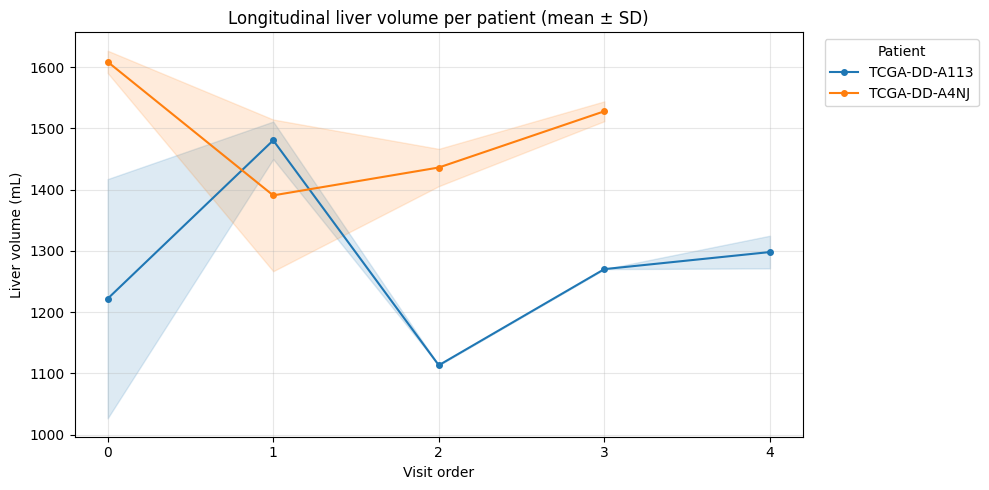

In [18]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/imperandi-demo/tables/nifti_index_radiomics.csv")

feature = "liver_original_shape_MeshVolume"
df[feature] = pd.to_numeric(df[feature], errors="coerce") / 1000  # mm³ → mL

data = (
    df.groupby(["patient_key", "visit_order"])[feature]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("visit_order")
)

fig, ax = plt.subplots(figsize=(10, 5))

for patient, group in data.groupby("patient_key"):
    x = group["visit_order"].to_numpy()
    y = group["mean"].to_numpy()
    std = group["std"].fillna(0).to_numpy()

    line, = ax.plot(x, y, "-o", label=str(patient), markersize=4)
    ax.fill_between(
        x, y - std, y + std,
        color=line.get_color(), alpha=0.15
    )

ax.set(
    xlabel="Visit order",
    ylabel="Liver volume (mL)",
    title="Longitudinal liver volume per patient (mean ± SD)",
)
ax.set_xticks(sorted(data["visit_order"].unique()))
ax.grid(alpha=0.3)
ax.legend(title="Patient", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Interactive IMPERANDI viewer

The viewer automatically discovers populated `mask_*` columns and provides patient/exam/modality/phase navigation, orthogonal planes, windowing, overlays, and slice controls.

In [14]:
from google.colab import output
output.enable_custom_widget_manager()

%matplotlib inline

from imperandi.qc.viewer import ScanViewer

viewer = ScanViewer(
    segmented,
    'nifti_path',
    phase_col='phase',
    exploration_mode='ordered',
    isotropic_resolution_mm=1.5,
)

## Full scientific benchmarks

This notebook is a functionality showcase. Reproducible comparisons against published TCGA-LIHC cohorts live separately under [`examples/benchmarks/`](../benchmarks/).